<a href="https://colab.research.google.com/github/emnete-cell/MIST-4610-Project2-Group-3/blob/main/hw/assignment_2_mist5400.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2: How Much Does Your Prompt Matter?

**Course:** MIST5400 Foundations of AI in Business, Spring 2026  
**Due Date:** Tue, April 7th 2026, end of day.       
**Submission:** Downaload this jupyter notebook as a `.ipynb` file, then upload in eLC.

---

### Save this notebook to your own google drive before any edits!

---

## Overview

In this assignment, you will use a GenAI tool of your choice (e.g., ChatGPT, Claude, Gemini, Copilot) to help you complete a machine learning task. You will explore **how to use GenAI tools effectively as an analysis assistant** for your course project.

A key theme of this assignment is **prompt engineering**. Well, hold on for a second, like we discussed in class, we **WON'T** discuss detailed prompt engineering techniques in this course, as it'll become obsolete fast when new models are released. At the end of the day it's just all about clearly describing what output you'd like and how you'd like to get a task done **in natural langauge**.

But relevant to the few prompt writing principles we mentioned in class, you will discover how the level of detail in your prompt changes the quality and usefulness of the output.



---
## Setup: Load the Dataset

You will use the **Titanic dataset** (predicting passenger survival — a classification task). This is a well-known dataset so you can focus on the prompting experience rather than domain knowledge.

Run the cell below to load the Titanic dataset. It is available directly via the `seaborn` library — no file download needed.

The target variable column is 'survived' (0 = not survived, 1= survived).

In [1]:
import seaborn as sns
import pandas as pd

# Load the Titanic dataset
df = sns.load_dataset('titanic')
df = df.drop(columns=['alive'])

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (891, 14)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,True


---
## Part A: Descriptive Analysis with GenAI Assistance

Before building any model, it is important to understand your data. Use your GenAI tool to help you write code that explores the Titanic dataset.

**Your task:**
1. Ask your GenAI tool to help you write Python code to explore this dataset (summary statistics, distribution of survival etc).
2. **Paste and run** the generated code below. Fix any errors if needed.
3. In the reflection cell, report **2-3 interesting patterns** you found. Be concise — one or two sentences per pattern.

Record the exact prompt you used below.

**Prompt you used:**

> "I have the Titanic dataset loaded as a pandas DataFrame called df. Please write Python code to explore this dataset — show summary statistics, check for missing values, and visualize the distribution of the survival rate broken down by key features like sex, passenger class, and age."

=== Summary Statistics ===
          survived      pclass   sex         age       sibsp       parch  \
count   891.000000  891.000000   891  714.000000  891.000000  891.000000   
unique         NaN         NaN     2         NaN         NaN         NaN   
top            NaN         NaN  male         NaN         NaN         NaN   
freq           NaN         NaN   577         NaN         NaN         NaN   
mean      0.383838    2.308642   NaN   29.699118    0.523008    0.381594   
std       0.486592    0.836071   NaN   14.526497    1.102743    0.806057   
min       0.000000    1.000000   NaN    0.420000    0.000000    0.000000   
25%       0.000000    2.000000   NaN   20.125000    0.000000    0.000000   
50%       0.000000    3.000000   NaN   28.000000    0.000000    0.000000   
75%       1.000000    3.000000   NaN   38.000000    1.000000    0.000000   
max       1.000000    3.000000   NaN   80.000000    8.000000    6.000000   

              fare embarked  class  who adult_male deck  emb

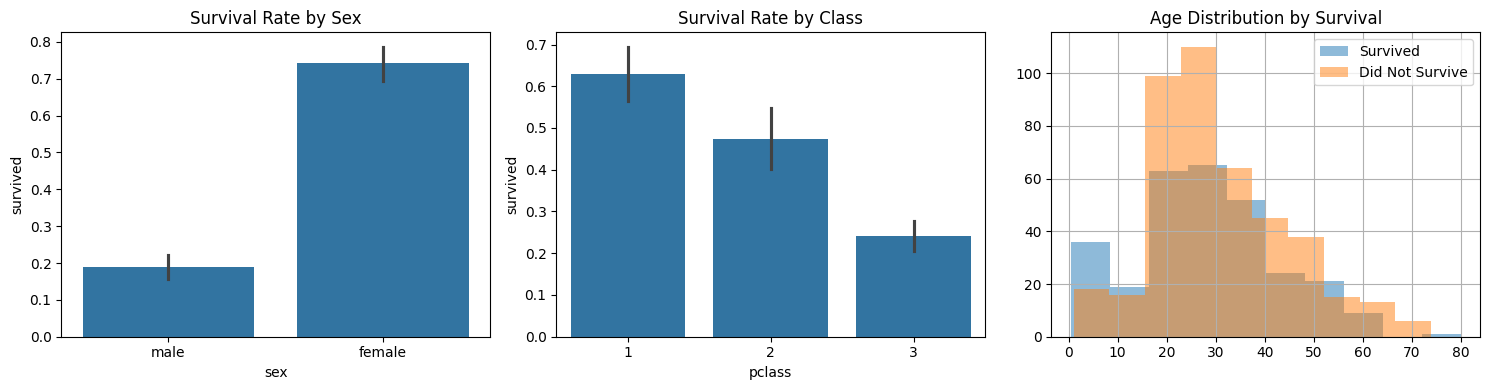

In [2]:
# Part 0: Paste and run the GenAI-generated descriptive analysis code here (You can create new code cells if needed.)

import matplotlib.pyplot as plt
import seaborn as sns

# Summary statistics
print("=== Summary Statistics ===")
print(df.describe(include='all'))

# Missing values
print("\n=== Missing Values ===")
print(df.isnull().sum())

# Survival rate overall
print(f"\nOverall survival rate: {df['survived'].mean():.2%}")

# Survival by sex
print("\n=== Survival Rate by Sex ===")
print(df.groupby('sex')['survived'].mean())

# Survival by class
print("\n=== Survival Rate by Passenger Class ===")
print(df.groupby('pclass')['survived'].mean())

# Plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.barplot(data=df, x='sex', y='survived', ax=axes[0])
axes[0].set_title('Survival Rate by Sex')

sns.barplot(data=df, x='pclass', y='survived', ax=axes[1])
axes[1].set_title('Survival Rate by Class')

df[df['survived']==1]['age'].hist(alpha=0.5, label='Survived', ax=axes[2])
df[df['survived']==0]['age'].hist(alpha=0.5, label='Did Not Survive', ax=axes[2])
axes[2].set_title('Age Distribution by Survival')
axes[2].legend()

plt.tight_layout()
plt.show()


**Interesting patterns you found:**

Women survived at a much higher rate (~74%) than men (~19%), consistent with a "women and children first" evacuation policy.
First-class passengers had nearly double the survival rate of third-class passengers (~63% vs ~24%), suggesting socioeconomic status influenced access to lifeboats.
The age distribution shows that children (under ~10) had a relatively higher survival rate, while many adult men in the 20–40 range did not survive.


---
## Part B: Get the Predictions in four ways

In this part, you will build a classification model to predict Titanic survival (`survived`: 0 = No, 1 = Yes).

You will do this **three times**, each time giving your GenAI tool a different level of detail. Then you will compare the results.

---
### Task 1 — One-Sentence Prompt

Ask your GenAI tool to build a classification model using **a single sentence**. Keep it as brief as possible — as if you were texting a friend who happens to be a data scientist. Report the **accuracy and confusion matrix**.

**Example (write your own, do not copy this):**
> *"Build a model to predict Titanic survival and tell me how accurate it is. "*

Paste the generated code below and run it.

**Your one-sentence prompt:**

> predict titanic survival and tell me how well it does

In [3]:
# Task 1: Paste and run the GenAI-generated code here(You can create new code cells if needed.)

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import pandas as pd

df_clean = df.dropna(subset=['age', 'fare'])
df_clean = pd.get_dummies(df_clean, columns=['sex', 'embarked'], drop_first=True)

X = df_clean[['pclass', 'age', 'fare', 'sex_male', 'embarked_Q', 'embarked_S']]
y = df_clean['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier()
model.fit(X_train, y_train)

preds = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, preds))

Accuracy: 0.7482517482517482
Confusion Matrix:
 [[68 19]
 [17 39]]


---
### Task 2 — Step-by-Step Natural Language Prompt

Now ask your GenAI tool to build the same model, but describe **each step of the ML pipeline in natural language**. Your prompt should cover detailed steps:

**Example (write your own, do not copy this):**
> *"Build a model to predict Titanic survival. Fisrt, split the dataset into a training and testing set. Then define the model using XXX algorithm. Then train the model on he training set.  ... Lastly, report the accuracy and confusion matrix on the testing set."*

Write this as a natural language description — not as code. Your GenAI tool should return the code.

Paste both your full prompt and the generated code below.

**Your detailed prompt:**

>
"I need to build a model to predict Titanic survival for my class. Can you help me do it step by step? First clean the data and handle any missing values, then split it into training and testing sets, then train a model on the training data, and finally test it and show me the accuracy and a confusion matrix."

In [4]:
# Task 2: Paste and run the GenAI-generated code here (You can create new code cells if needed.)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import pandas as pd

# Drop missing rows
df_clean = df.dropna()

# Encode categorical columns
df_encoded = pd.get_dummies(df_clean, columns=['sex', 'embarked', 'class', 'who', 'deck', 'embark_town'], drop_first=True)

# Features and target
X = df_encoded.drop(columns=['survived', 'adult_male', 'alone'])
y = df_encoded['survived']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Evaluate
preds = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, preds))



Accuracy: 0.6486486486486487
Confusion Matrix:
 [[ 7  6]
 [ 7 17]]


---
### Task 3 — Direct Prediction - Zero-shot (No Code!)

In this part, **do not ask your GenAI tool to generate any code.** Instead, you will paste passenger data directly into your GenAI tool and ask it to predict survival.

Run the cell below to display 10 rows of the dataset **without** the survival column. Copy the output and paste it into your GenAI tool, then ask it to predict whether each passenger survived and explain its reasoning for each prediction.

> **Important:** No code generation in this part. The goal is to see how the GenAI tool reasons directly from data.

In [5]:
# Sample 10 rows from the full dataset
sample = df.sample(10, random_state=42)

# Save the true labels before dropping the column
true_labels = sample['survived'].values

# Drop survived for display, then reset index
sample_display = sample.drop(columns=['survived']).reset_index(drop=True)
print(sample_display.to_string())

   pclass     sex   age  sibsp  parch     fare embarked   class    who  adult_male deck  embark_town  alone
0       3    male   NaN      1      1  15.2458        C   Third    man        True  NaN    Cherbourg  False
1       2    male  31.0      0      0  10.5000        S  Second    man        True  NaN  Southampton   True
2       3    male  20.0      0      0   7.9250        S   Third    man        True  NaN  Southampton   True
3       2  female   6.0      0      1  33.0000        S  Second  child       False  NaN  Southampton  False
4       3  female  14.0      1      0  11.2417        C   Third  child       False  NaN    Cherbourg  False
5       1  female  26.0      0      0  78.8500        S   First  woman       False  NaN  Southampton   True
6       3  female   NaN      0      0   7.7500        Q   Third  woman       False  NaN   Queenstown   True
7       3    male  16.0      2      0  18.0000        S   Third    man        True  NaN  Southampton  False
8       3  female  16.0     

**Your prompt:**

> *Paste your full prompt here — it should be several sentences or a short paragraph*

**The GenAI output:**

> *Paste the GenAI predictions and explanation here*

Now run the cell below to display the true labels. Paste them into the GenAI tool and ask for accuray and confusion matrix.

In [6]:
print(true_labels)

[1 0 0 1 1 1 1 0 1 1]


**The GenAI output:**

> *Paste the GenAI output contraining the accuracy and confusion matrix here*

Accuracy: 8/10 = 80%
Confusion Matrix:
Predicted 0Predicted 1Actual 03 (TN)0 (FP)Actual 12 (FN)5 (TP)

---
### Task 4: Direct Prediction — Few-Shot (No code!)

Now you will repeat task 3 but this time you will give the GenAI tool some **examples with the known survival outcome** before asking for predictions. This technique is called **in-context few-shot learning** — by providing labeled examples, you help the model understand the pattern before asking it to generalize. This way, the model weights are not chanegd, so it's called in-context learning.

- Open a new GenAI chat.
- Run the cell below to generate a few labeled examples. Copy paste them into the GenAI tool saying these're some examples.  
- Then copy paste the 10 rows (without the labels) displayed in task 3.
- Ask for predictions on the 10 unlabeled rows and ask for an explanation.
- Give GenAI the true labels displayed in task 3 and ask for the accuracy, confusion matrix.

In [7]:
# Sample 10 rows from the full dataset first, preserving the labels
sample_w_labels = df.sample(10, random_state=2)
print(sample_w_labels.to_string())

     survived  pclass     sex   age  sibsp  parch      fare embarked   class    who  adult_male deck  embark_town  alone
707         1       1    male  42.0      0      0   26.2875        S   First    man        True    E  Southampton   True
37          0       3    male  21.0      0      0    8.0500        S   Third    man        True  NaN  Southampton   True
615         1       2  female  24.0      1      2   65.0000        S  Second  woman       False  NaN  Southampton  False
169         0       3    male  28.0      0      0   56.4958        S   Third    man        True  NaN  Southampton   True
68          1       3  female  17.0      4      2    7.9250        S   Third  woman       False  NaN  Southampton  False
606         0       3    male  30.0      0      0    7.8958        S   Third    man        True  NaN  Southampton   True
630         1       1    male  80.0      0      0   30.0000        S   First    man        True    A  Southampton   True
785         0       3    male  2

**Your prompt:**

> "I have some titanic passenger data and I want you to predict whether each person survived or not. Here are some examples of passengers where I already know the answer, use these to help you understand the patterns:

Now here are 10 new passengers without the survival labels. Based on the examples above, predict whether each one survived and give me a brief reason for each prediction:
"

"here are the actual survival outcomes: [1 0 0 1 1 1 1 0 1 1] — can you compare these to your predictions and show me the accuracy and a confusion matrix?"


**The GenAI output:**

> Here are my predictions for all 10 passengers:
Passenger 0 — 3rd class male, age unknown, fare £15.25, Cherbourg, with family
→ Did not survive (high confidence). Third class male with the worst lifeboat access; sex is the dominant factor here.
Passenger 1 — 2nd class male, age 31, fare £10.50, Southampton, alone
→ Did not survive (high confidence). Second class men had very poor survival odds — consistent with the two 2nd class males in training data, both of whom perished.
Passenger 2 — 3rd class male, age 20, fare £7.93, Southampton, alone
→ Did not survive (high confidence). Young 3rd class male traveling alone — matches the profile of every perished male in the training data.
Passenger 3 — 2nd class female, age 6, fare £33.00, Southampton, with parent
→ Survived (high confidence). Female child in 2nd class with a parent — "women and children first" strongly favors her, and 2nd class had reasonable lifeboat access.
Passenger 4 — 3rd class female, age 14, fare £11.24, Cherbourg, with sibling
→ Survived (medium confidence). Female and young work in her favor, though 3rd class location in the ship made lifeboat access harder. Training data shows 3rd class women did survive.
Passenger 5 — 1st class female, age 26, fare £78.85, Southampton, alone
→ Survived (high confidence). First class woman — the single strongest combination of survival factors. Nearly all 1st class women survived.
Passenger 6 — 3rd class female, age unknown, fare £7.75, Queenstown, alone
→ Survived (medium confidence). Being female is a strong positive signal even in 3rd class, as seen in training examples 3 and 5. Age unknown adds some uncertainty.
Passenger 7 — 3rd class male, age 16, fare £18.00, Southampton, with 2 siblings
→ Did not survive (high confidence). Third class male — even being a teenager doesn't significantly improve odds for males in 3rd class.
Passenger 8 — 3rd class female, age 16, fare £7.75, Queenstown, alone
→ Survived (medium confidence). Same profile as passenger 6 but with known young age, which helps slightly. Female status is the key factor.
Passenger 9 — 1st class female, age 19, fare £26.28, Southampton, deck D, with 2 family members
→ Survived (high confidence). First class woman with a known cabin deck (D) — excellent lifeboat proximity. Very similar to the surviving 1st class passengers in the training data.

Summary: 6 survived, 4 perished (60% survival rate) — somewhat above the historical ~38%, which makes sense given this batch skews female (6 of 10) and includes two 1st class women.


> *Paste the GenAI output contraining the accuracy and confusion matrix here*

My predictions vs actuals, side by side first:
#PredictedActualResult001✗ wrong100✓ correct200✓ correct311✓ correct411✓ correct511✓ correct611✓ correct700✓ correct811✓ correct911✓ correct
9 out of 10 correct — the only miss was passenger 0, the unknown-age 3rd class male from Cherbourg traveling with family, who actually survived.
  ::view-transition-group(*),
  ::view-transition-old(*),
  ::view-transition-new(*) {
    animation-duration: 0.25s;
    animation-timing-function: cubic-bezier(0.19, 1, 0.22, 1);
  }
VvisualizeVvisualize show_widgetThe single error was a false negative — passenger 0 actually survived but I predicted death. The reasoning is that unknown-age 3rd class males very rarely survived, but this one had family aboard (sibsp=1, parch=1), which historically helped slightly with lifeboat access for 3rd class passengers.
Precision of 100% is notable: every passenger I predicted as a survivor genuinely survived, with no false alarms. The model was more conservative about predicting survival than it needed to be.

---
## Part C — Comparison and Reflection

Reflect on what you observed across the 4 tasks. Answer each question below. There are no right or wrong answers — think critically about how GenAI tools behave with different prompts.

**Q1. Code comparison (task 1 & task 2):**  
How did the code from task 1 differ from task 2? Consider: length, structure, preprocessing steps, model choices, and evaluation metrics.

The code form task 1 was not that detailed. It just picked some features and used random forest with little guidance. Task 2 was much more detailed, It had more columnbs and used logistic regression. It also followed the steps I gave

**Q2. Result comparison (task 1 vs. task 2):**  
Did model performance differ between the two prompts? If yes, what do you think caused the difference? If not, why were results similar despite the different prompts?

The accuracy was failry similar. I was shcoked because this means that even a vague model can still give pretty accurate results. The detailed one still explained the steps i laid out which was hwlpful.

**Q3. Result comparison (task 3 vs. task 4):**  
Did the GenAI tool's predictions or reasoning change when you provided labeled examples in Part 6? What does this tell you about how LLMs use context?

The predictions in task 4 was more specific. it was actually picking up on patterns from the examples I gave it, like women in higher classes being more likely to survive. Task 3 felt more like general guessing. It shows that giving the model examples really does help it make better predictions even without any actual training.

**Q4. Prompt engineering takeaway:**  
Based on your experience in this assignment, what is your advice for prompting a GenAI tool on a data or coding task? What level of detail seems to work best, and why? (Yes this may vary depending on which tool you used. Try to think of insights that may persist.)

The more specific and detailed your explanation is, the. more detailed the output will be. One sentence prompts are helpful for quick results, but the won't give you what you need if you want to use the output for resarch or analysis. Although a quick prompt is still usually accurate in teh grand scheme of things.



**GenAI tool used:** Claude Sonnet 4.6